In [ ]:
from optimade.client import OptimadeClient

# Initialize the client
client = OptimadeClient()

In [4]:
client.base_urls


['https://aflow.org/API/optimade/',
 'https://alexandria.icams.rub.de/pbesol',
 'https://alexandria.icams.rub.de/pbe',
 'https://www.crystallography.net/cod/optimade',
 'https://cmr-optimade.fysik.dtu.dk/',
 'https://aiida.materialscloud.org/mc3d/optimade',
 'https://aiida.materialscloud.org/mc2d/optimade',
 'https://aiida.materialscloud.org/2dtopo/optimade',
 'https://aiida.materialscloud.org/tc-applicability/optimade',
 'https://aiida.materialscloud.org/pyrene-mofs/optimade',
 'https://aiida.materialscloud.org/curated-cofs/optimade',
 'https://aiida.materialscloud.org/stoceriaitf/optimade',
 'https://aiida.materialscloud.org/autowannier/optimade',
 'https://aiida.materialscloud.org/tin-antimony-sulfoiodide/optimade',
 'https://optimade.materialscloud.org/archive/c8-gy',
 'https://optimade.materialscloud.org/archive/5p-vq',
 'https://optimade.materialscloud.org/archive/vg-ya',
 'https://optimade.materialsproject.org/',
 'http://mpddoptimade.phaseslab.org/',
 'https://api.mpds.io/',
 '

In [ ]:
base_url = "https://aiida.materialscloud.org/mc3d/optimade"
client = OptimadeClient(base_urls=[base_url])
formula =  "Si02"
query = f'chemical_formula_reduced="{formula}"'
response = client.get(filter=query)
len((response['structures'][query][base_url]['data']))

In [13]:
# Define the chemical formula to search for
original_formula = "SiO2"

import re

# Function to swap elements in the formula
def swap_formula(formula):
    elements = re.findall(r"[A-Z][a-z]?\d*", formula)  # Extract element-symbol + count
    swapped_formula = "".join(reversed(elements))  # Reverse order
    return swapped_formula

swap_formula(original_formula)

'O2Si'

In [78]:
#Read Training Data

In [28]:
TRAINING_DATA_PATH = "./data/alpaca_mbj_bandgap_train.json"
GENERATED_DATA_PATH =  "./2_gen_mbj_bandgap/material_generated_samples_database_added.csv"

In [2]:
import pandas as pd 
from datasets import load_dataset
import re

data_train = load_dataset("json", data_files=TRAINING_DATA_PATH, split="train")
df_gen = pd.read_csv(GENERATED_DATA_PATH)

/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Regex pattern to match chemical formulas (capital letters followed by numbers)
text = "The chemical formula is Te3SeO8. The  mbj_bandgap value is 4.382."
match = re.search(r'\b[A-Z][a-z]?\d*(?:[A-Z][a-z]?\d*)*\b', text)
match.group()

'Te3SeO8'

In [3]:
for each in data_train["input"]:
        match = re.search(r'\b[A-Z][a-z]?\d*(?:[A-Z][a-z]?\d*)*\b', each)
        formula = match.group()

        matches = df_gen['formula'].str.contains(rf'\b{formula}\b', regex=True, na=False)

        df_gen.loc[matches, 'Match_Found'] = True
        df_gen.loc[matches, 'Matched_Formula'] = formula

        # df_gen['Match_Found'] = df_gen['Match_Found'].fillna(False)
        # df_gen['Matched_Formula'] = df_gen['Matched_Formula'].fillna(False)

df_gen.to_csv(f"./2_gen_mbj_bandgap/material_generated_samples_database_added_tr_check_added.csv", index=False)


In [4]:
df_gen

,prompt,response,formula,expected_prop_val,after_alignn_prop_val,gen_material_str,gen_material_cif,Alexandria,Alexandria_id,MC3D,MC3D_id,OQMD,OQMD_id,JARVIS,JARVIS_id,MaterialsProject,MaterialsProject_id,Match_Found,Matched_Formula
0,Below is a description of a superconductor mat...,Below is a description of a superconductor mat...,SiH,3.711,NaN,3.9 3.9 5.0\n90 90 120\nSi\n0.33 0.67 0.93\nSi...,# generated using pymatgen\ndata_SiH\n_symmetr...,1.0,agm002086366,1.0,50707.0,11.0,4067700.0,2.0,dft_2d_JVASP-6808,1.0,mp-29803,True,SiH
1,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,HO,3.114,NaN,3.3 3.3 3.3\n90 90 90\nH\n0.00 0.00 0.00\nH\n0...,# generated using pymatgen\ndata_H2O2\n_symmet...,NaN,NaN,2.0,4687.0,8.0,4384824.0,8.0,dft_3d_JVASP-12577,2.0,mp-23939,True,HO
2,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,HC,3.811,NaN,3.7 3.7 3.7\n109 109 109\nH\n0.39 0.00 0.50\nH...,# generated using pymatgen\ndata_HC\n_symmetry...,2.0,agm003163144,2.0,232425.0,12.0,4482003.0,13.0,dft_3d_JVASP-101785,4.0,mp-995197,True,HC
3,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,HN,4.062,NaN,3.4 3.4 3.4\n109 109 108\nH\n0.75 0.75 -0.00\n...,# generated using pymatgen\ndata_HN\n_symmetry...,1.0,agm003240882,3.0,278619.0,13.0,4468545.0,5.0,dft_3d_JVASP-134971,4.0,mp-720515,NaN,NaN
4,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,AlH,3.261,NaN,3.6 3.6 5.1\n90 90 90\nAl\n0.50 0.50 0.39\nAl\...,# generated using pymatgen\ndata_AlH\n_symmetr...,NaN,NaN,NaN,NaN,8.0,4480989.0,3.0,dft_3d_JVASP-139255,NaN,NaN,True,AlH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18895,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,FmPb,4.368,NaN,6.4 6.4 6.4\n33 33 33\nFm\n0.50 0.50 0.50\nPb\...,# generated using pymatgen\ndata_FmPb\n_symmet...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18896,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,FmSn,3.690,NaN,4.7 4.7 4.7\n60 60 60\nFm\n0.00 0.00 0.00\nSn\...,# generated using pymatgen\ndata_FmSn\n_symmet...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18897,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,FmMo,4.595,NaN,3.8 3.8 3.8\n90 90 90\nFm\n0.50 0.50 0.50\nMo\...,# generated using pymatgen\ndata_FmMo\n_symmet...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18898,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,FmIn,3.674,NaN,3.8 3.8 3.8\n90 90 90\nFm\n0.50 0.50 0.50\nIn\...,# generated using pymatgen\ndata_FmIn\n_symmet...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_726220/235018089.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=["Matched", "Unmatched"], y=[match_counts.get(True, 0), unmatched_count], palette=['green', 'red'])


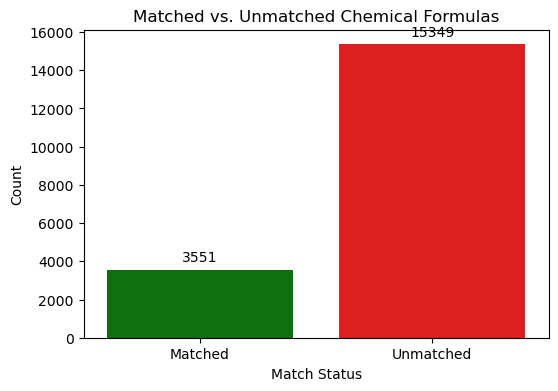

In [102]:
# Count matched and unmatched
match_counts = df_gen['Match_Found'].value_counts()
unmatched_count = df_gen['Match_Found'].isna().sum()

# Plot
plt.figure(figsize=(6, 4))
barplot = sns.barplot(x=["Matched", "Unmatched"], y=[match_counts.get(True, 0), unmatched_count], palette=['green', 'red'])

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     fontsize=10, color='black', 
                     xytext=(0, 9),  # Offset the text a bit
                     textcoords='offset points')
    
# Labels and title
plt.xlabel("Match Status")
plt.ylabel("Count")
plt.title("Matched vs. Unmatched Chemical Formulas")
plt.xticks(ticks=[0, 1], labels=["Matched", "Unmatched"])

# Show plot
plt.show()
#waterfall plot, Sankey plot, visualization (put percentange instead of numbers, )
#RMSI metrics, (distrbution) (design space 20K, test set, ABC errors)(3Angstrom - 10A) lattice parameters prediction, predict the materials ABC (convert into atom )

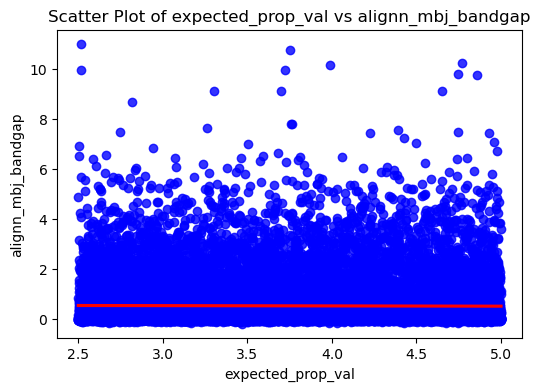

In [110]:
# Create scatter plot using seaborn
plt.figure(figsize=(6, 4))
sns.regplot(x='expected_prop_val', y='alignn_mbj_bandgap', data=df_gen, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})


# Labels and title
plt.xlabel("expected_prop_val")
plt.ylabel("alignn_mbj_bandgap")
plt.title("Scatter Plot of expected_prop_val vs alignn_mbj_bandgap")

# Show plot
plt.show()

In [115]:
df_gen['Difference'] = abs(df_gen['expected_prop_val'] - df_gen['alignn_mbj_bandgap'])
# Find the row with the minimum difference
min_diff_row = df_gen.loc[df_gen['Difference'].idxmin()]

# Sort the DataFrame by the difference (ascending)
sorted_df = df_gen.sort_values(by='Difference')


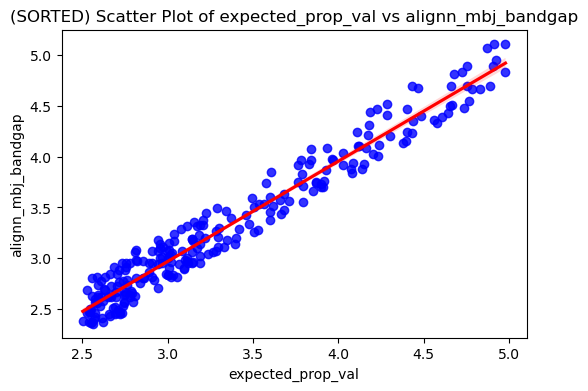

In [120]:
plt.figure(figsize=(6, 4))
sns.regplot(x='expected_prop_val', y='alignn_mbj_bandgap', data=sorted_df.head(250), scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})


# Labels and title
plt.xlabel("expected_prop_val")
plt.ylabel("alignn_mbj_bandgap")
plt.title("(SORTED) Scatter Plot of expected_prop_val vs alignn_mbj_bandgap")

# Show plot
plt.show()

In [121]:
sorted_df.head(100)['formula']

#LiSe 4
#SeLi 3.5
#(chech those structure)

8859      LiSe
12745     KrO2
184        PbF
18636       BS
12451     TiO2
         ...  
9046      MgTe
7045     Cl3O2
3496     Cd2O3
6919     Na3O2
8972       SnO
Name: formula, Length: 100, dtype: object

In [125]:
from collections import Counter
import re

# Function to split formula into elements
def split_elements(formula):
    # Regular expression to extract elements and their counts (e.g., "Li", "O2")
    return re.findall(r'[A-Z][a-z]?', formula)

formulas = sorted_df.head(100)['formula']

# Split each formula and count occurrences of each element
all_elements = []
for formula in formulas:
    elements = split_elements(formula)
    all_elements.extend(elements)

# Count the occurrences of each element
element_counts = Counter(all_elements)
sorted_elements_by_count = sorted(element_counts.items(), key=lambda x: x[1], reverse=True)

# Output the results
print("Elements sorted by count (descending):")
for element, count in sorted_elements_by_count:
    print(f"{element}: {count}")

Elements sorted by count (descending):
O: 30
S: 15
Se: 14
N: 13
C: 10
Cl: 8
F: 6
P: 6
Xe: 6
Ga: 6
B: 5
Al: 5
Br: 5
Kr: 4
Pb: 4
Zn: 4
Te: 4
Ne: 4
As: 3
Mg: 3
Ar: 3
I: 3
Ba: 3
H: 3
Dy: 3
Li: 2
Ti: 2
Rb: 2
Rn: 2
In: 2
Si: 2
Cd: 2
Ge: 2
Cs: 2
Na: 2
Ra: 1
Lu: 1
Sc: 1
Sr: 1
Po: 1
K: 1
He: 1
Sn: 1
